# 고령인구 10만명당 노인복지시설 · 요양병원 수 상관관계 분석

**3조 "지역별 의료 인프라 격차 분석" — 고령화 파트**

기존 분석(고령인구비율 vs 노인복지관 수)에 이어, 아래 두 지표를 추가로 확인한다.

1. 고령인구비율 vs **고령인구 10만명당 노인복지시설 수** (경로당·노인복지관 등 시설 합계, 규모보정)
2. 고령인구비율 vs **고령인구 10만명당 요양병원 수** (건강보험심사평가원, KOSIS Open API `DT_MIRE01`, 2024년 4분기 기준)

절대량이 아닌 "고령인구 10만명당"으로 정규화해, 인구 규모가 큰 지역(경기·서울 등)이
시설 수도 단순히 많아지는 규모 효과를 제거한 뒤 상관관계를 본다.

데이터 출처: `data/aging/processed/aging_master.csv`
(생성: `python -m src.aging.preprocess.preprocess_aging`)

┌─────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────┐
│            항목             │                                      방식                                       │
├─────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────┤
│ 노인복지시설(경로당·복지관) │ data.go.kr 첨부 CSV 직접 다운로드 (collect_senior_facilities.py, requests)      │
├─────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────┤
│ 고령인구비율(행안부)        │ HTML 정적 스크래핑 (collect_aging_population.py, requests+BeautifulSoup)        │
├─────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────┤
│ 요양병원 수(이번 건)        │ KOSIS 공식 Open API 호출 (collect_kosis_api.py, requests, JSON) — 스크래핑 아님 │
└─────────────────────────────┴─────────────────────────────────────────────────────────────────────────────────┘

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# 프로젝트 루트 찾기 (이 노트북은 notebooks/aging/ 에 위치)
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data" / "aging").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.aging.analysis.correlation import interpret  # noqa: E402

MASTER_PATH = PROJECT_ROOT / "data" / "aging" / "processed" / "aging_master.csv"
master = pd.read_csv(MASTER_PATH)
master.head()

,시도,기준연도,총인구수,고령인구수_65세이상,고령인구비율,노인복지관수,경로당수,노인복지시설_합계,요양병원수,인구10만명당_노인복지관수,고령인구1만명당_노인복지관수,인구10만명당_경로당수,고령인구10만명당_노인복지시설수,고령인구10만명당_요양병원수
0,전라남도,2024,1788819,486492,27.20,33,9275,10269,79,1.84,0.68,518.50,2110.83,16.24
1,경상북도,2024,2531384,659227,26.04,23,8090,9186,103,0.91,0.35,319.59,1393.45,15.62
2,강원특별자치도,2024,1517766,384970,25.36,17,3350,4149,32,1.12,0.44,220.72,1077.75,8.31
3,전북특별자치도,2024,1738690,439263,25.26,32,6880,7914,74,1.84,0.73,395.70,1801.65,16.85
4,부산광역시,2024,3266598,780576,23.90,34,2423,3424,160,1.04,0.44,74.18,438.65,20.50


In [2]:
# ── 한글 폰트 설정 (Windows 기본 맑은 고딕 — 없으면 각 OS의 한글 폰트로 교체) ──
import matplotlib.font_manager as fm

for _candidate in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if any(_candidate == f.name for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _candidate
        break
plt.rcParams["axes.unicode_minus"] = False

# ── dataviz 스타일: 단일 계열 sequential 강조색 + 얇은 마크 (Streamlit 대시보드와 동일 톤) ──
ACCENT = "#2563eb"
TREND_COLOR = "#94a3b8"
GRID_COLOR = "#e2e8f0"


def scatter_with_corr(df: pd.DataFrame, x_col: str, y_col: str, x_label: str, y_label: str, title: str):
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    slope, intercept = np.polyfit(x, y, 1)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=110)

    # 추세선 (OLS)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=TREND_COLOR, linewidth=2, zorder=1)

    # 산점 (단일 계열 = 단색, 얇은 흰 테두리로 겹침 구분)
    ax.scatter(x, y, s=90, color=ACCENT, edgecolor="white", linewidth=1.2, zorder=2)

    # 시도 라벨 (17개 포인트 전부 직접 라벨링 — 범례 불필요)
    for xi, yi, name in zip(x, y, df["시도"]):
        ax.annotate(name, (xi, yi), textcoords="offset points", xytext=(6, 5), fontsize=8, color="#334155")

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    stat_text = (
        f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.4f})\n"
        f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.4f})\n"
        f"n = {len(df)} · {interpret(pearson_r)}"
    )
    ax.text(
        0.02, 0.98, stat_text, transform=ax.transAxes, fontsize=9.5,
        verticalalignment="top", color="#1e293b",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=GRID_COLOR),
    )

    plt.tight_layout()
    plt.show()

    return {
        "x": x_col, "y": y_col, "pearson_r": round(pearson_r, 3), "pearson_p": round(pearson_p, 4),
        "spearman_r": round(spearman_r, 3), "spearman_p": round(spearman_p, 4), "n": len(df),
    }

## 1) 고령인구비율 vs 고령인구 10만명당 노인복지시설 수

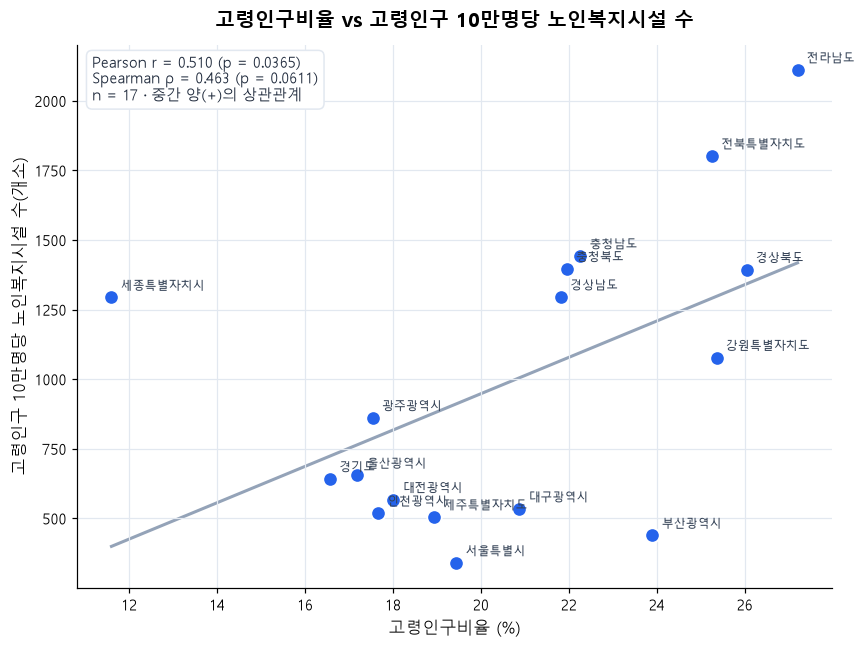

{'x': '고령인구비율',
 'y': '고령인구10만명당_노인복지시설수',
 'pearson_r': np.float64(0.51),
 'pearson_p': np.float64(0.0365),
 'spearman_r': np.float64(0.463),
 'spearman_p': np.float64(0.0611),
 'n': 17}

In [3]:
result_1 = scatter_with_corr(
    master,
    x_col="고령인구비율", y_col="고령인구10만명당_노인복지시설수",
    x_label="고령인구비율 (%)", y_label="고령인구 10만명당 노인복지시설 수(개소)",
    title="고령인구비율 vs 고령인구 10만명당 노인복지시설 수",
)
result_1

## 2) 고령인구비율 vs 고령인구 10만명당 요양병원 수

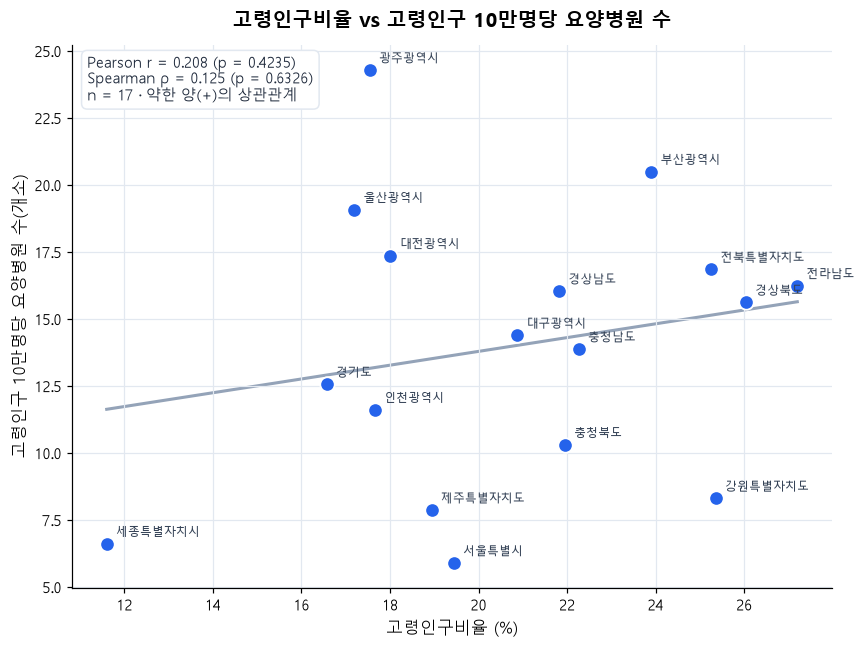

{'x': '고령인구비율',
 'y': '고령인구10만명당_요양병원수',
 'pearson_r': np.float64(0.208),
 'pearson_p': np.float64(0.4235),
 'spearman_r': np.float64(0.125),
 'spearman_p': np.float64(0.6326),
 'n': 17}

In [4]:
result_2 = scatter_with_corr(
    master,
    x_col="고령인구비율", y_col="고령인구10만명당_요양병원수",
    x_label="고령인구비율 (%)", y_label="고령인구 10만명당 요양병원 수(개소)",
    title="고령인구비율 vs 고령인구 10만명당 요양병원 수",
)
result_2

## 결과 요약

| 지표 쌍 | Pearson r | p-value | 해석 |
|---|---|---|---|
| 고령인구비율 vs 고령인구 10만명당 노인복지시설 수 | 약 0.51 | 0.037 (유의) | 중간 강도 양의 상관관계 |
| 고령인구비율 vs 고령인구 10만명당 요양병원 수 | 약 0.21 | 0.424 (유의하지 않음) | 뚜렷한 상관관계 없음 |

- **노인복지시설**(경로당·노인복지관 등 복지 인프라)은 고령화가 심한 지역일수록 인구 규모 대비
  공급이 더 많은 경향이 통계적으로 유의하게 나타난다(기존 "고령인구비율 vs 노인복지관 수" 결과와 방향 일치).
- **요양병원**(의료기관)은 고령화율과의 상관관계가 약하고 통계적으로 유의하지 않다. 즉 요양병원 입지는
  고령인구 비율보다 병상 수요·수익성·도시 접근성 등 다른 요인(인구 밀집도, 교통 등)의 영향을 더 크게
  받을 가능성을 시사한다 — 팀 공통 목표인 "고령화율 vs 병상수" 분석과 함께 교차 검증이 필요하다.
- 두 결과 모두 `data/aging/processed/correlation_result.csv`의 산출값과 일치한다(재현: `python -m src.aging.analysis.correlation`).

---

## 3) 연도별 패널 분석 (2015~2024)

지금까지는 2024년 한 시점만 봤다. 여기서는 같은 두 지표(고령인구 10만명당 노인복지시설 수 /
요양병원 수)를 **2015~2024년 매년 반복 계산**해서, 고령화율과의 상관관계가 시간이 지나며
강해지는지·약해지는지·부호가 바뀌는지를 본다.

- 각 연도는 n=17(시도)짜리 독립된 횡단면 상관계수다 — 패널회귀(고정효과 모델)가 아니라
  "연도별 스냅샷 상관계수를 나란히 늘어놓은 것"이라는 점에 주의.
- 데이터 출처: 노인복지시설(2015~2024, data.go.kr), 요양병원(2015~2024, data.go.kr —
  건강보험심사평가원 원자료, KOSIS 2024년 4분기 수치와 교차검증 완료), 고령인구(2015~2024,
  행정안전부 주민등록인구통계 매년 12월 스냅샷 10회 수집)
- 파이프라인: `python -m src.aging.collect.collect_aging_population_timeseries` →
  `python -m src.aging.preprocess.build_panel` → `python -m src.aging.analysis.correlation_by_year`

In [5]:
panel = pd.read_csv(PROJECT_ROOT / "data" / "aging" / "processed" / "aging_panel_2015_2024.csv")
corr_by_year = pd.read_csv(PROJECT_ROOT / "data" / "aging" / "processed" / "correlation_by_year.csv")
panel.head()

,시도,연도,총인구수,고령인구수_65세이상,고령인구비율,노인복지시설_합계,요양병원수,고령인구10만명당_노인복지시설수,고령인구10만명당_요양병원수
0,전라남도,2015,1908996,391837,20.53,9108,67,2324.44,17.10
1,전북특별자치도,2015,1869711,333524,17.84,6808,82,2041.23,24.59
2,경상북도,2015,2702826,479634,17.75,8033,112,1674.82,23.35
3,강원특별자치도,2015,1549507,261671,16.89,3233,30,1235.52,11.46
4,충청남도,2015,2077649,341214,16.42,5756,67,1686.92,19.64


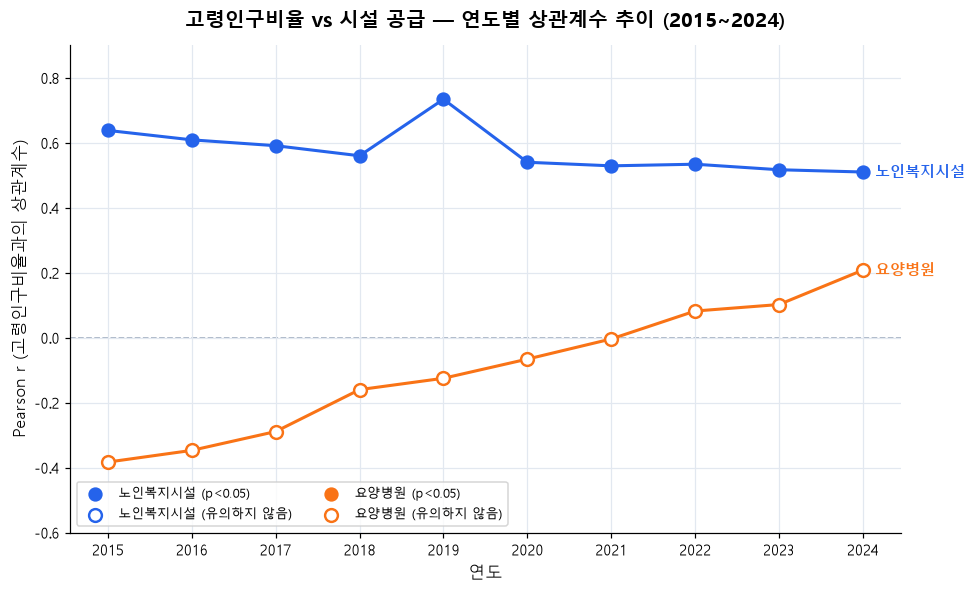

In [6]:
# ── 연도별 Pearson r 추이 (단일 축, 2개 계열 — dual-axis 대신 같은 스케일(r: -1~1)에 겹쳐 그림) ──
FACILITY_COLOR = ACCENT              # 노인복지시설 (기존 산점도와 동일 색)
HOSPITAL_COLOR = "#f97316"           # 요양병원 (구분되는 두 번째 계열색)

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=110)

def _plot_trend(y_col: str, label: str, color: str):
    sub = corr_by_year[corr_by_year["y"] == y_col].sort_values("연도")
    sig = sub["pearson_p"] < 0.05
    ax.plot(sub["연도"], sub["pearson_r"], color=color, linewidth=2, zorder=2)
    ax.scatter(sub.loc[sig, "연도"], sub.loc[sig, "pearson_r"], color=color, s=70, zorder=3, label=f"{label} (p<0.05)")
    ax.scatter(sub.loc[~sig, "연도"], sub.loc[~sig, "pearson_r"], facecolor="white", edgecolor=color,
               linewidth=1.6, s=70, zorder=3, label=f"{label} (유의하지 않음)")
    ax.annotate(label, (sub["연도"].iloc[-1], sub["pearson_r"].iloc[-1]),
                textcoords="offset points", xytext=(8, 0), fontsize=10, color=color, fontweight="bold",
                va="center")
    return sub

_plot_trend("고령인구10만명당_노인복지시설수", "노인복지시설", FACILITY_COLOR)
_plot_trend("고령인구10만명당_요양병원수", "요양병원", HOSPITAL_COLOR)

ax.axhline(0, color="#94a3b8", linewidth=1, linestyle="--", zorder=1)
ax.set_xlabel("연도", fontsize=11)
ax.set_ylabel("Pearson r (고령인구비율과의 상관계수)", fontsize=11)
ax.set_title("고령인구비율 vs 시설 공급 — 연도별 상관계수 추이 (2015~2024)", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(sorted(panel["연도"].unique()))
ax.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(-0.6, 0.9)
ax.legend(loc="lower left", fontsize=8.5, frameon=True, ncol=2)

plt.tight_layout()
plt.show()

**읽는 법**: 채워진 점 = 통계적으로 유의(p<0.05), 빈 점(테두리만) = 유의하지 않음.

- **노인복지시설**(파란선): 10년 내내 꾸준히 **유의한 양의 상관관계**(r = 0.51~0.73)를 유지한다.
  2019년에 잠깐 튀어오른 것(r=0.73) 외에는 완만히 낮아지는 추세지만, 방향(양의 상관)은 한 번도
  안 바뀌었다 — "고령화가 심한 지역일수록 복지시설이 많다"는 관계가 지난 10년간 구조적으로
  안정적이라는 뜻이다.
- **요양병원**(주황선): 훨씬 극적이다. **2015~2017년엔 뚜렷한 음의 상관(r=-0.29~-0.38)**이었다가
  2021년 즈음 0을 가로지르고, **2024년엔 약한 양의 상관(r=0.21)**으로 부호 자체가 바뀌었다
  (다만 전 기간 p>0.05로 통계적 유의성은 없음 — 방향성은 뚜렷하지만 "유의한 관계"라고 단정하긴 이름).
  해석하면: 2015년 무렵엔 요양병원이 오히려 고령화율이 *낮은* 지역(=아직 인구·의료 인프라가
  두꺼운 대도시)에 더 많이 몰려 있었는데, 지난 10년 사이 고령화가 심한 지역으로 공급이 서서히
  옮겨가는 재편이 있었다고 읽을 수 있다. 다음 단계로는 이 사이 어떤 지역에서 요양병원 수가
  가장 크게 늘었는지(연도별 증감)를 봐야 더 확실한 원인을 말할 수 있다.

### 3-1) 노인복지시설 — 연도별 산점도 (2015~2024, 축 고정)

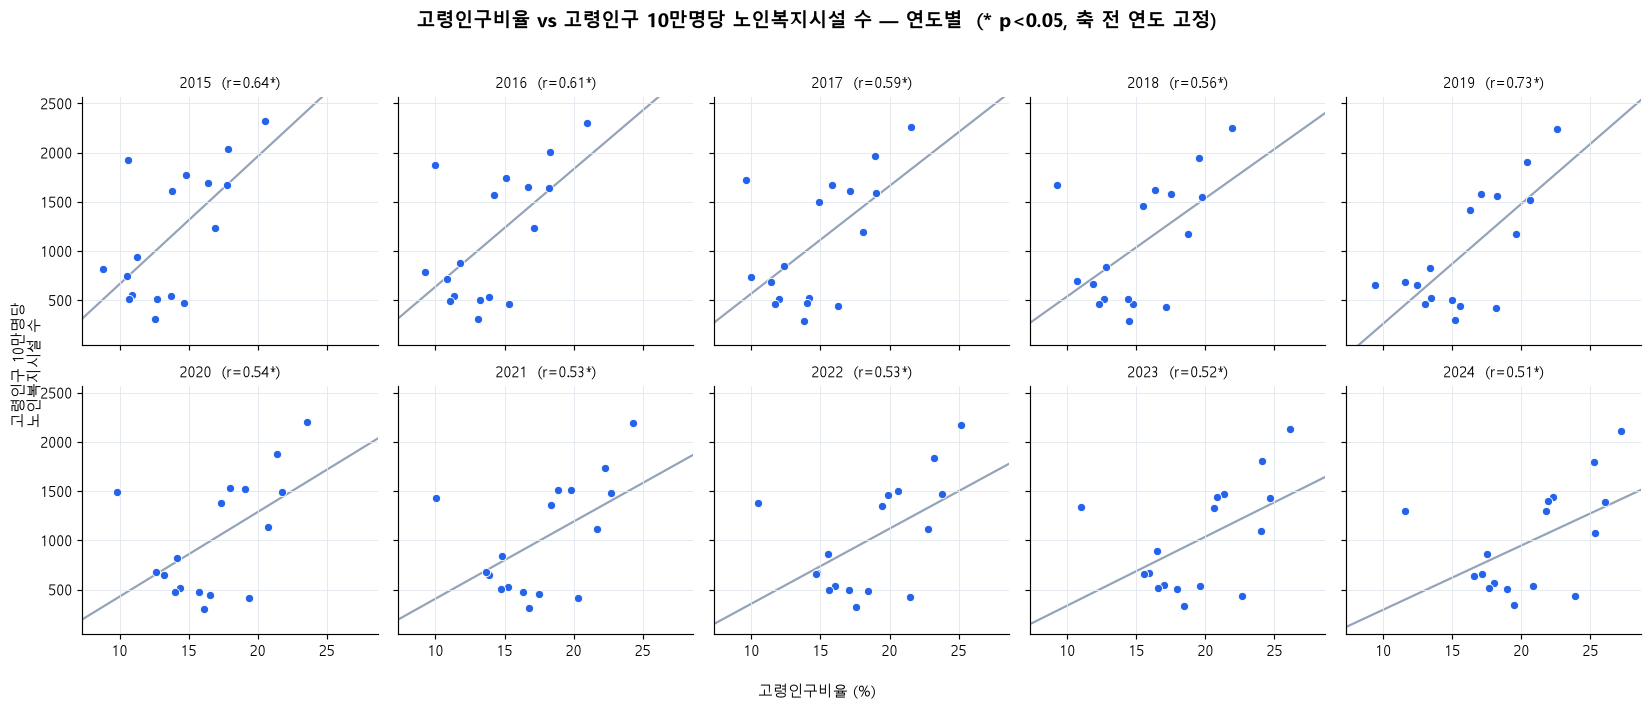

In [7]:
def small_multiples(y_col: str, y_label: str, color: str, suptitle: str):
    years = sorted(panel["연도"].unique())
    x_all, y_all = panel["고령인구비율"], panel[y_col]
    xpad = (x_all.max() - x_all.min()) * 0.08
    ypad = (y_all.max() - y_all.min()) * 0.12
    xlim = (x_all.min() - xpad, x_all.max() + xpad)
    ylim = (y_all.min() - ypad, y_all.max() + ypad)

    fig, axes = plt.subplots(2, 5, figsize=(16, 6.5), dpi=105, sharex=True, sharey=True)
    for ax, year in zip(axes.flat, years):
        sub = panel[panel["연도"] == year]
        x, y = sub["고령인구비율"].to_numpy(float), sub[y_col].to_numpy(float)
        r, p = stats.pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(*xlim, 50)
        ax.plot(x_line, slope * x_line + intercept, color=TREND_COLOR, linewidth=1.5, zorder=1)
        ax.scatter(x, y, s=32, color=color, edgecolor="white", linewidth=0.6, zorder=2)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f"{year}  (r={r:.2f}{'*' if p < 0.05 else ''})", fontsize=10)
        ax.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(suptitle + "  (* p<0.05, 축 전 연도 고정)", fontsize=13, fontweight="bold", y=1.02)
    fig.supxlabel("고령인구비율 (%)", fontsize=10)
    fig.supylabel(y_label, fontsize=10)
    plt.tight_layout()
    plt.show()


small_multiples(
    "고령인구10만명당_노인복지시설수", "고령인구 10만명당\n노인복지시설 수", FACILITY_COLOR,
    "고령인구비율 vs 고령인구 10만명당 노인복지시설 수 — 연도별",
)

### 3-2) 요양병원 — 연도별 산점도 (2015~2024, 축 고정)

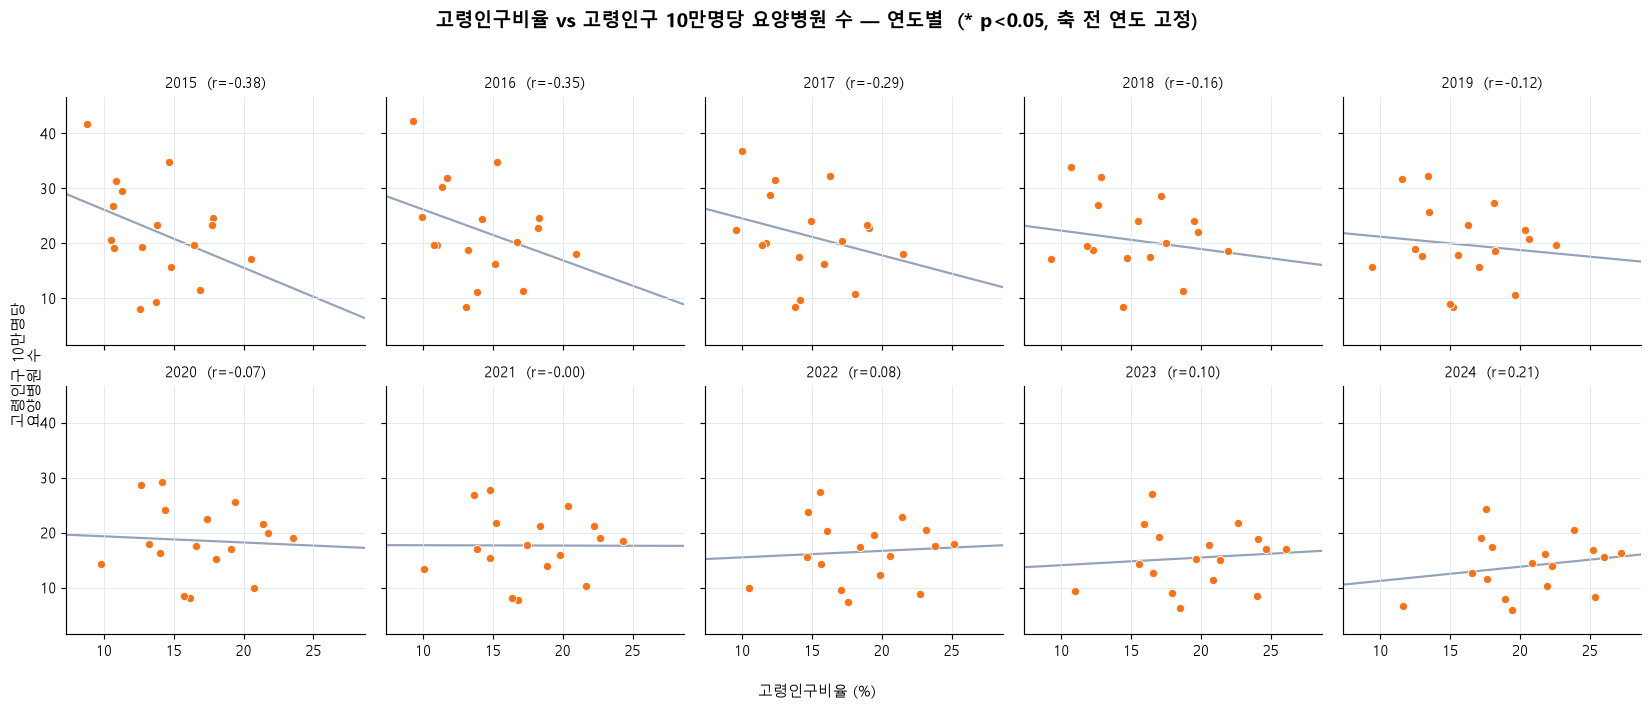

In [8]:
small_multiples(
    "고령인구10만명당_요양병원수", "고령인구 10만명당\n요양병원 수", HOSPITAL_COLOR,
    "고령인구비율 vs 고령인구 10만명당 요양병원 수 — 연도별",
)

## 최종 결론 (2015~2024 패널 포함)

| 지표 | 2024 단면 r | 2015~2024 추이 | 해석 |
|---|---|---|---|
| 고령인구비율 vs 고령인구10만명당 노인복지시설 수 | 0.51 (유의) | 0.64→0.51, 항상 유의한 양의 상관 | **구조적으로 안정된 관계** — 복지 정책이 고령화 수요를 꾸준히 따라감 |
| 고령인구비율 vs 고령인구10만명당 요양병원 수 | 0.21 (유의X) | **-0.38→+0.21, 부호 반전** | 유의하진 않지만 **뚜렷한 방향 전환** — 요양병원 입지가 점차 고령화 지역 쪽으로 재편되는 신호 |

10년치로 보면
**"관계가 없는 게 아니라, 관계의 방향이 바뀌는 중"** 이라는 훨씬 풍부한 그림이 나온다.
